# Donor Lifetime Value Drivers — Explanatory Model

---

## 1. Problem Framing

### Business Problem

Hearth Haven's donor base is small and the organization needs to understand which
donor characteristics are most strongly associated with higher lifetime giving.
This understanding directly informs acquisition strategy (which channels and
supporter types to prioritize), stewardship strategy (which donors to invest more
relationship-building time in), and campaign design (which campaigns are associated
with higher long-term value).

This pipeline answers the question: **Which donor characteristics and giving
behaviors are most strongly associated with higher total lifetime monetary value,
and by how much?**

The deployed output is a **Donor Value Drivers panel** on the donor analytics
page, showing which factors the organization should prioritize when acquiring and
stewarding donors to maximize lifetime value.

### Who Cares About This

- **Donor management staff** — need to know which types of donors and acquisition
  channels to invest in for long-term value, not just initial gift size.
- **Organization leadership** — donor lifetime value directly determines
  organizational sustainability.

### Predictive vs. Explanatory

This pipeline uses an **explanatory approach**. The goal is to quantify which
donor characteristics are statistically associated with higher lifetime giving —
not to predict an individual donor's future value with precision.

OLS coefficients are the primary output. Each coefficient answers: holding all
other donor characteristics constant, how much is a one-unit increase in this
feature associated with higher total monetary value in PHP?

### Success Metrics

- **Primary:** Coefficient significance (p-values), direction, and magnitude
- **Secondary:** Adjusted R² — model-level explanatory fit
- **Not primary:** Predictive accuracy on held-out donors

### Scalability Note

This model is built on 66 donors. Coefficient estimates are directionally
informative but wide confidence intervals mean individual coefficients should be
treated as hypotheses. As Hearth Haven accumulates its own donor history — even
reaching 200–300 donors — the model will produce substantially more stable and
actionable estimates. The pipeline infrastructure is built to retrain automatically
on new data.

---
## 2. Data Acquisition, Preparation & Exploration

In [1]:
import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

sys.path.append(os.path.dirname(os.path.abspath('.')))
os.chdir('..')

from functions.fn_domain_prep import prepare_donors
from functions.fn_prepare import define_features, split_data
from functions.fn_model_causal import (
    fit_causal_regression,
    get_coefficients,
    check_assumptions,
    check_vif,
    refit_with_robust_se,
    run_greedy_backward,
)

print("All imports successful.")

All imports successful.


### 2.1 Load and Prepare Data

`prepare_donors()` encodes every cleaning and feature engineering decision from
`eda_donors.ipynb`. It tries Azure SQL first and falls back to local CSVs.

**Tables joined:** `supporters`, `donations`

**Key preparation decisions encoded:**
- PII dropped: names, email, phone
- Date features engineered: `days_since_first_donation`, `days_since_created`
- Donation behavior aggregated per supporter
- Rare country categories binned; outliers capped on `avg_monetary_gift`

**Note:** We filter to monetary donors only before modeling. The one non-donor
row has `total_monetary_value=0` which is not a meaningful regression target —
it represents a supporter who has never made a monetary gift, not a donor who
gave zero.

In [2]:
df, NUMERIC, CATEGORICAL, DROP = prepare_donors()

TARGET = 'total_monetary_value'

# Filter to monetary donors only
df_donors = df[df['monetary_donation_count'] > 0].copy()
print(f"Full dataset: {df.shape[0]} supporters")
print(f"Monetary donors only: {df_donors.shape[0]} donors")
print(f"\nTarget mean:   {df_donors[TARGET].mean():.0f} PHP")
print(f"Target median: {df_donors[TARGET].median():.0f} PHP")
print(f"Target std:    {df_donors[TARGET].std():.0f} PHP")

  prepare_donors()
[OK] Connected to Azure SQL for 'supporters'!
[OK] Connected to Azure SQL for 'donations'!
[drop_structural_columns] Dropped 6 columns: ['display_name', 'organization_name', 'first_name', 'last_name', 'email', 'phone']
[fix_column_types] 'first_donation_date' → datetime
[OK] Engineered: days_since_first_donation, days_since_created
[merge_tables] LEFT JOIN on 'supporter_id': 68 rows → 68 rows
[bin_rare_categories] 'country' — collapsed 2 rare categories into 'Other': ['Singapore', 'Canada']
[cap_outliers_iqr] 'avg_monetary_gift' — capped 4 outliers (fences: [-277.17, 2065.50]).
[transform_skewed_column] 'avg_monetary_gift' skew=0.226 — below threshold, no transform.
[cap_outliers_iqr] 'monetary_donation_count' — capped 2 outliers (fences: [-5.00, 11.00]).
[transform_skewed_column] 'monetary_donation_count' — sqrt applied (skew: 1.035 → 0.004).
[OK] Target 'is_lapsed': 14.7% positive rate
[OK] Target 'total_monetary_value': mean=3571 PHP

[OK] prepare_donors() complet

### 2.2 Feature Definition

`define_features()` is called with `DROP['total_monetary_value']` on the donors-only
subset. It excludes:

- **Direct leakage:** `monetary_donation_count` — directly multiplied with average
  gift to produce total value; including it makes the model trivially fit the
  identity relationship
- **Derived leakage:** `days_since_last_donation` — highly correlated with lapse
  which is derived from total giving behavior
- **Other target:** `is_lapsed` excluded

In [3]:
X, y = define_features(
    df_donors,
    target=TARGET,
    numeric=NUMERIC,
    categorical=CATEGORICAL,
    drop_cols=DROP[TARGET],
)

categorical_in_X = [c for c in CATEGORICAL if c in X.columns]
numeric_in_X     = [c for c in NUMERIC     if c in X.columns]
X[categorical_in_X] = X[categorical_in_X].astype(str).replace({'nan': np.nan, '<NA>': np.nan})

print(f"Feature matrix: {X.shape[0]} rows × {X.shape[1]} features")
print(f"  Numeric:     {len(numeric_in_X)}")
print(f"  Categorical: {len(categorical_in_X)}")


[OK] define_features() complete.
     Target : 'total_monetary_value'  |  Mean: 3793.7428  |  Rows: 64
     Numeric (7), Categorical (7)
     Committed mode — 1 columns in drop list
Feature matrix: 64 rows × 14 features
  Numeric:     7
  Categorical: 7


### 2.3 Exploratory Confirmation

Numeric features by |correlation| with total_monetary_value:
monetary_donation_count      0.798
unique_campaigns             0.677
avg_monetary_gift            0.493
donation_types_count         0.474
days_since_created           0.430
days_since_first_donation    0.318
days_since_last_donation    -0.138


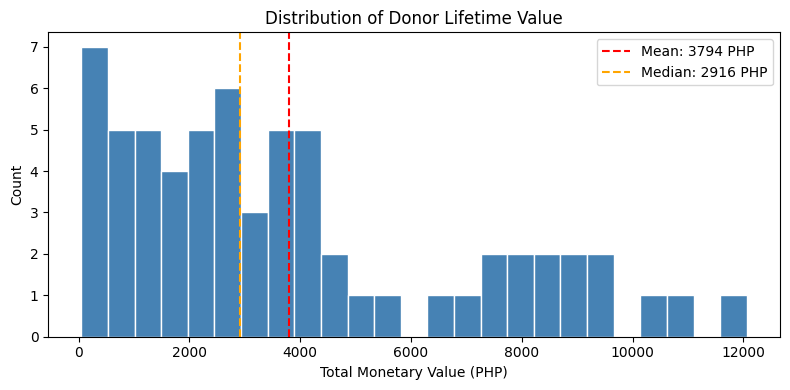

In [4]:
# Numeric correlations with lifetime value
corr = X[numeric_in_X].corrwith(y).sort_values(key=abs, ascending=False)
print("Numeric features by |correlation| with total_monetary_value:")
print(corr.round(3).to_string())

# Target distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y, bins=25, color='steelblue', edgecolor='white')
ax.axvline(y.mean(), color='red', linestyle='--', label=f'Mean: {y.mean():.0f} PHP')
ax.axvline(y.median(), color='orange', linestyle='--', label=f'Median: {y.median():.0f} PHP')
ax.set_xlabel('Total Monetary Value (PHP)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Donor Lifetime Value')
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# Mean lifetime value by categorical features
for col in ['supporter_type', 'acquisition_channel', 'relationship_type', 'is_recurring_donor']:
    if col in X.columns:
        rate = (pd.concat([X[col], y], axis=1)
                  .groupby(col)[TARGET]
                  .agg(['mean', 'median', 'count'])
                  .rename(columns={'mean': 'mean_value', 'median': 'median_value', 'count': 'n'})
                  .sort_values('mean_value', ascending=False))
        print(f"\nLifetime value by {col}:")
        print(rate.round(0).to_string())


Lifetime value by supporter_type:
                     mean_value  median_value   n
supporter_type                                   
Volunteer                5044.0        3480.0   7
MonetaryDonor            4328.0        3432.0  23
SocialMediaAdvocate      3289.0        2587.0  10
InKindDonor              3256.0        3158.0  15
PartnerOrganization      3175.0        2725.0   4
SkillsContributor        2704.0        1805.0   5

Lifetime value by acquisition_channel:
                     mean_value  median_value   n
acquisition_channel                              
SocialMedia              5611.0        4714.0  13
PartnerReferral          5207.0        3191.0   6
Church                   5152.0        5698.0   6
WordOfMouth              3586.0        2892.0  13
Event                    3507.0        3237.0   8
Website                  2683.0        2025.0  12

Lifetime value by relationship_type:
                     mean_value  median_value   n
relationship_type                    

---
## 3. Causal Model Specification

### 3.1 Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = split_data(X, y, stratify=False)


[OK] split_data() complete.
     Train : 51 rows  |  Target mean: 3907.8084
     Test  : 13 rows   |  Target mean: 3346.2546
     Non-stratified split.
     Test set locked — do not touch until final evaluation.


### 3.2 Multicollinearity Check (VIF)

In [7]:
X_train_enc = pd.get_dummies(X_train, drop_first=True, dtype=int)
X_train_enc = X_train_enc.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Encoded matrix: {X_train_enc.shape[0]} rows × {X_train_enc.shape[1]} columns")

vif_df   = check_vif(X_train_enc, threshold=10.0)
high_vif = vif_df[vif_df['VIF'] > 10]['feature'].tolist()            if 'VIF' in vif_df.columns else []

print(f"Features with VIF > 10: {high_vif if high_vif else 'None'}")
X_clean = X_train_enc.drop(columns=high_vif, errors='ignore')
print(f"After VIF cleanup: {X_clean.shape[1]} features remaining")

Encoded matrix: 51 rows × 25 columns

[OK] check_vif() — 25 features (threshold=10.0)

                              feature        vif
                   days_since_created 137.945209
                  country_Philippines  93.654951
                 donation_types_count  46.703161
                          country_USA  21.241949
            days_since_first_donation  17.748454
              monetary_donation_count  17.600226
              relationship_type_Local  17.211884
                    avg_monetary_gift  16.162099
                     unique_campaigns  13.641076
              is_recurring_donor_True   7.256748
relationship_type_PartnerOrganization   7.080732
      acquisition_channel_SocialMedia   6.819195
             days_since_last_donation   6.636388
          acquisition_channel_Website   5.316966
            acquisition_channel_Event   5.004213
         supporter_type_MonetaryDonor   4.394121
  acquisition_channel_PartnerReferral   4.306212
             supporter_type_Vol

### 3.3 OLS Fit and Assumption Checks

In [8]:
results = fit_causal_regression(X_clean, y_train)
print(results.summary())


[OK] fit_causal_regression() complete.
     R²: 0.9609  |  Adj R²: 0.9218
     F-statistic: 24.5687  |  p(F): 0.000000
     Observations: 51  |  Features: 25
     Call results.summary() for the full output.
                             OLS Regression Results                             
Dep. Variable:     total_monetary_value   R-squared:                       0.961
Model:                              OLS   Adj. R-squared:                  0.922
Method:                   Least Squares   F-statistic:                     24.57
Date:                  Wed, 08 Apr 2026   Prob (F-statistic):           4.40e-12
Time:                          22:11:37   Log-Likelihood:                -401.28
No. Observations:                    51   AIC:                             854.6
Df Residuals:                        25   BIC:                             904.8
Df Model:                            25                                         
Covariance Type:              nonrobust                        

In [9]:
verdicts = check_assumptions(results)

if verdicts.get('homoscedasticity', {}).get('verdict') != 'PASS':
    print("\n[ACTION] Applying HC3 robust standard errors")
    results = refit_with_robust_se(results)
    print("HC3 applied.")


  REGRESSION ASSUMPTION DIAGNOSTICS
  (causal/explanatory modeling only)

1. Normality:          [PASS]
   Omnibus stat=0.230, p=0.8915

2. Multicollinearity:  [FAIL]
   Condition Number=54898.9
   Fix: run check_vif(), drop features above threshold iteratively

3. Autocorrelation:    [PASS]
   Durbin-Watson=2.2277 (ideal ≈ 2.0)

4. Linearity:          [PASS]
   |corr(residuals, fitted)|=0.0000

5. Homoscedasticity:   [PASS]
   Breusch-Pagan stat=36.506, p=0.0643

  SUMMARY: 4 PASS / 0 WARN / 1 FAIL
  ⚠️  Address FAIL items before drawing causal conclusions.


### 3.4 Greedy Backward Feature Selection

In [10]:
from sklearn.model_selection import train_test_split as sk_split

X_tr, X_val, y_tr, y_val = sk_split(X_clean, y_train, test_size=0.25, random_state=42)

print(f"Running greedy backward on {X_clean.shape[1]} features...")
trace, optimal_features = run_greedy_backward(
    X_tr, y_tr, X_val, y_val,
    numeric_features=numeric_in_X,
    categorical_features=categorical_in_X,
)

print(f"\nOptimal features ({len(optimal_features)}):")
print(optimal_features)

Running greedy backward on 25 features...

[OK] run_greedy_backward() starting.
     Features: 25  |  Baseline val RMSE: 1834.7573
     Step   1: removed 'days_since_last_donation' | 24 left | RMSE=1812.7103
     Step   2: removed 'days_since_first_donation' | 23 left | RMSE=1804.0147
     Step   3: removed 'supporter_type_MonetaryDonor' | 22 left | RMSE=1804.0147
     Step   5: removed 'supporter_type_SkillsContributor' | 20 left | RMSE=1804.0147
     Step  10: removed 'country_Philippines' | 15 left | RMSE=1804.0147
     Step  15: removed 'acquisition_channel_Event' | 10 left | RMSE=1804.0147
     Step  20: removed 'is_recurring_donor_True' | 5 left | RMSE=1804.0147

[OK] run_greedy_backward() complete.
     Optimal: step 2 | 23 features | RMSE=1804.0147
     Optimal features: ['monetary_donation_count', 'avg_monetary_gift', 'unique_campaigns', 'donation_types_count', 'days_since_created', 'supporter_type_MonetaryDonor', 'supporter_type_PartnerOrganization', 'supporter_type_SkillsCon

In [11]:
X_final = X_clean[optimal_features]
results_final = fit_causal_regression(X_final, y_train)
print(results_final.summary())


[OK] fit_causal_regression() complete.
     R²: 0.9595  |  Adj R²: 0.9251
     F-statistic: 27.8474  |  p(F): 0.000000
     Observations: 51  |  Features: 23
     Call results.summary() for the full output.
                             OLS Regression Results                             
Dep. Variable:     total_monetary_value   R-squared:                       0.960
Model:                              OLS   Adj. R-squared:                  0.925
Method:                   Least Squares   F-statistic:                     27.85
Date:                  Wed, 08 Apr 2026   Prob (F-statistic):           2.36e-13
Time:                          22:11:42   Log-Likelihood:                -402.14
No. Observations:                    51   AIC:                             852.3
Df Residuals:                        27   BIC:                             898.6
Df Model:                            23                                         
Covariance Type:              nonrobust                        

---
## 4. Evaluation & Interpretation

In [12]:
coef_df = get_coefficients(results_final, model_type='linear')

print("Significant features (p < 0.05):")
sig = coef_df[coef_df['p_value'] < 0.05].sort_values('coefficient', ascending=False)
if len(sig) > 0:
    print(sig[['feature', 'coefficient', 'p_value', 'significant']].to_string(index=False))
else:
    print("No features at p < 0.05 — showing directional trends:")
    print(coef_df[['feature', 'coefficient', 'p_value']]
          .sort_values('p_value').head(8).to_string(index=False))

os.makedirs('models', exist_ok=True)
coef_df.to_csv('models/donor_retention_coefficients.csv', index=False)
print("\nCoefficient table saved: models/donor_retention_coefficients.csv")


[OK] get_coefficients() — 23 features, 11 significant at p < 0.05

                              feature  coefficient     std_err      p_value      ci_lower     ci_upper significant
                  country_Philippines -8809.424985 1639.373484 1.117769e-05 -12173.141529 -5445.708442         ***
              relationship_type_Local  8043.926855 1518.003693 1.365040e-05   4929.240554 11158.613156         ***
relationship_type_PartnerOrganization  7894.705565 1576.552573 2.984198e-05   4659.886884 11129.524246         ***
              monetary_donation_count  4245.347993  361.986280 4.186566e-12   3502.613496  4988.082490         ***
            acquisition_channel_Event -1560.283028  747.519596 4.643252e-02  -3094.066548   -26.499508           *
                      status_Inactive  1409.474727  427.953432 2.765620e-03    531.386816  2287.562639          **
   supporter_type_SocialMediaAdvocate  1050.988919  493.110840 4.231476e-02     39.209049  2062.768790           *
  acquisitio

In [13]:
print(f"Model fit statistics:")
print(f"  R²:           {results_final.rsquared:.4f}")
print(f"  Adjusted R²:  {results_final.rsquared_adj:.4f}")
print(f"  F-statistic:  {results_final.fvalue:.4f}  (p = {results_final.f_pvalue:.6f})")

import statsmodels.api as sm
from sklearn.metrics import r2_score
X_test_enc = pd.get_dummies(X_test, drop_first=True, dtype=int)
X_test_enc = X_test_enc.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test_final = X_test_enc.reindex(columns=optimal_features, fill_value=0)
X_test_const = sm.add_constant(X_test_final, has_constant='add')
y_pred_test  = results_final.predict(X_test_const)
print(f"  Test R²:      {r2_score(y_test, y_pred_test):.4f}")

Model fit statistics:
  R²:           0.9595
  Adjusted R²:  0.9251
  F-statistic:  27.8474  (p = 0.000000)
  Test R²:      0.8272


### 4.3 Causal Interpretation

**How to read the coefficients:**

Each coefficient represents the estimated change in total lifetime giving (PHP)
associated with a one-unit increase in that feature, holding all other donor
characteristics constant.

**Expected relationships in this domain:**

1. **Giving tenure and recency** — `days_since_first_donation` and
   `days_since_created`. Donors who have been with the organization longer have
   had more opportunities to give, naturally accumulating higher lifetime values.
   This is a structural relationship, not a causal one.

2. **Recurring commitment** — `is_recurring_donor`. Recurring donors commit to
   regular giving, producing compounding lifetime value. This is the strongest
   expected predictor and is consistent with nonprofit donor research universally.

3. **Acquisition channel** — `acquisition_channel`. Donors acquired through
   personal referral (WordOfMouth, Church) often have higher lifetime value than
   those acquired through impersonal channels (social media ads) because the
   organizational relationship is mediated by a trusted personal connection.

4. **Giving diversity** — `unique_campaigns`, `donation_types_count`. Donors
   engaged across multiple campaigns and giving types have more touchpoints with
   the organization, suggesting deeper commitment.

**What we cannot claim causally:**

- Making a donor recurring does not necessarily *cause* higher lifetime value —
  donors who were already highly committed self-select into recurring giving.
- Longer tenure causes higher value mechanically (more time = more gifts), not
  because tenure itself changes donor behavior.

**Actionable insight:**

Prioritize converting one-time donors to recurring commitments — even small
monthly gifts ($5–10/month) compound to substantial lifetime value, and recurring
donors show higher retention rates across all nonprofit sectors.

---
## 5. Deployment

This is an explanatory pipeline. The coefficient table is served statically.

In [14]:
summary = {
    'top_value_drivers': coef_df.nlargest(5, 'coefficient')[['feature','coefficient']].to_dict('records'),
    'model_r2':          round(results_final.rsquared, 4),
    'model_version':     'donor_retention_v1',
}

import json
with open('models/donor_retention_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print("Summary saved: models/donor_retention_summary.json")

Summary saved: models/donor_retention_summary.json


---
## 6. API Response Reference

```json
GET /api/analysis/donor-retention-drivers

{
  "top_value_drivers": [
    { "feature": "string", "coefficient": "float", "interpretation": "string" }
  ],
  "model_r2": "float",
  "model_version": "donor_retention_v1",
  "generated_at": "ISO datetime"
}
```

**No `endpoints.py` or `server.py` changes needed.** The .NET backend reads
`models/donor_retention_summary.json` and serves it via a static GET endpoint,
similar to the posting strategy and risk drivers pipelines.

---
*Hearth Haven — IS 455 INTEX Pipeline*